In [1]:
!pip install torch torchvision pennylane matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 99.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

In [3]:

import torch
import torchvision
import torchvision.transforms as transforms

# Restart kernel before running this
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

# Fetch first batch
images, labels = next(iter(dataloader))
print("Batch shape:", images.shape)  # Expected: [batch_size, 1, 32, 32]


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Batch shape: torch.Size([64, 1, 32, 32])


In [4]:
def forward(self, noise):
    # Split latent space: Part for quantum, part for classical
    quantum_input = noise[:, :n_qubits]
    
    # Convert quantum output to FLOAT
    quantum_output = torch.tensor([quantum_layer(q) for q in quantum_input]).to(noise.device).float()

    classical_input = noise[:, n_qubits:]
    merged_input = torch.cat((quantum_output, classical_input), dim=1)

    x = self.fc(merged_input).view(-1, 128, 1, 1)
    img = self.conv_layers(x)
    return img


In [5]:
import torch
import torch.nn as nn
import pennylane as qml

# Quantum circuit parameters
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class Generator(nn.Module):
    def __init__(self, z_dim, img_channels):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.img_channels = img_channels

        # Fully connected layer
        self.fc = nn.Linear(z_dim, 128 * 8 * 8)

        # Deconvolutional layers for upsampling
        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # Upsample to 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1),  # Upsample to 32x32
            nn.Tanh()  # Normalize to [-1, 1]
        )

    def forward(self, noise):
        # Quantum component: first `n_qubits` of the noise vector go through the quantum layer
        quantum_input = noise[:, :n_qubits]
        quantum_output = torch.tensor([quantum_layer(q) for q in quantum_input]).to(noise.device).float()

        # Combine quantum and classical latent space
        classical_input = noise[:, n_qubits:]
        merged_input = torch.cat((quantum_output, classical_input), dim=1)

        x = self.fc(merged_input).view(-1, 128, 8, 8)  # Reshape to 8x8 feature map
        img = self.conv_layers(x)
        return img


In [6]:
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),  # Downsample to 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # Downsample to 8x8
            nn.LeakyReLU(0.2),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 8 * 8, 1)  # Adjusted based on feature map size
        self.sigmoid = nn.Sigmoid()

    def forward(self, img):
        x = self.conv_layers(img)
        x = self.flatten(x)
        x = self.fc(x)
        return self.sigmoid(x)


In [7]:
z_dim = 100  # Latent space size
img_channels = 1  # MNIST is grayscale (for CIFAR-10, use img_channels=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator(z_dim, img_channels).to(device)
discriminator = Discriminator(img_channels).to(device)


In [8]:
# optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
# criterion = nn.BCELoss()


In [9]:
# Define the optimizers before training
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion = nn.BCELoss()  # Binary Cross-Entropy loss for GAN


Epoch [1/50] | D Loss: 1.0135 | G Loss: 0.6434
Epoch [2/50] | D Loss: 0.9812 | G Loss: 1.4309
Epoch [3/50] | D Loss: 0.9494 | G Loss: 1.6082
Epoch [4/50] | D Loss: 0.7925 | G Loss: 1.5030
Epoch [5/50] | D Loss: 0.8122 | G Loss: 1.7866
Epoch [6/50] | D Loss: 0.7177 | G Loss: 1.5579
Epoch [7/50] | D Loss: 0.7221 | G Loss: 1.2521
Epoch [8/50] | D Loss: 0.6653 | G Loss: 1.8702
Epoch [9/50] | D Loss: 0.6983 | G Loss: 1.7465
Epoch [10/50] | D Loss: 0.8213 | G Loss: 0.9931


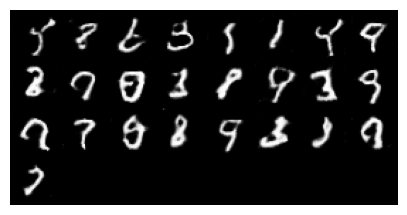

Epoch [11/50] | D Loss: 0.5622 | G Loss: 2.2577
Epoch [12/50] | D Loss: 0.6410 | G Loss: 2.6954
Epoch [13/50] | D Loss: 0.6734 | G Loss: 1.3713
Epoch [14/50] | D Loss: 0.7550 | G Loss: 2.8599
Epoch [15/50] | D Loss: 1.0805 | G Loss: 3.2212
Epoch [16/50] | D Loss: 0.6106 | G Loss: 1.8868
Epoch [17/50] | D Loss: 0.5544 | G Loss: 3.4962
Epoch [18/50] | D Loss: 0.4018 | G Loss: 2.6353
Epoch [19/50] | D Loss: 0.6255 | G Loss: 1.6398
Epoch [20/50] | D Loss: 0.5488 | G Loss: 2.7934


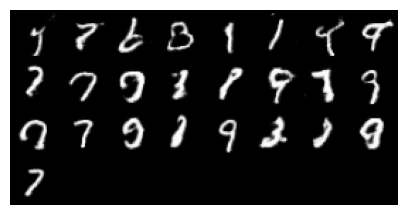

Epoch [21/50] | D Loss: 0.5475 | G Loss: 2.7103
Epoch [22/50] | D Loss: 0.5489 | G Loss: 2.2421
Epoch [23/50] | D Loss: 0.6034 | G Loss: 1.1165
Epoch [24/50] | D Loss: 0.4584 | G Loss: 2.0065
Epoch [25/50] | D Loss: 0.3921 | G Loss: 3.0695
Epoch [26/50] | D Loss: 0.3257 | G Loss: 2.7921
Epoch [27/50] | D Loss: 0.2906 | G Loss: 2.3308
Epoch [28/50] | D Loss: 0.3615 | G Loss: 3.9624
Epoch [29/50] | D Loss: 0.2192 | G Loss: 3.3551
Epoch [30/50] | D Loss: 0.3318 | G Loss: 2.4498


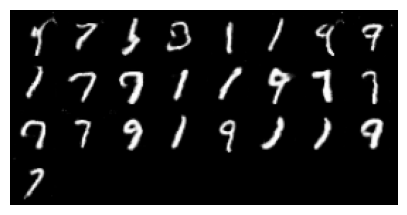

Epoch [31/50] | D Loss: 0.3630 | G Loss: 2.4446
Epoch [32/50] | D Loss: 0.2288 | G Loss: 3.0816
Epoch [33/50] | D Loss: 0.1923 | G Loss: 3.3564
Epoch [34/50] | D Loss: 0.2662 | G Loss: 4.0105
Epoch [35/50] | D Loss: 0.4247 | G Loss: 1.8979
Epoch [36/50] | D Loss: 0.1905 | G Loss: 3.2402
Epoch [37/50] | D Loss: 0.2348 | G Loss: 3.0858
Epoch [38/50] | D Loss: 0.3522 | G Loss: 3.4579
Epoch [39/50] | D Loss: 0.2201 | G Loss: 3.4746
Epoch [40/50] | D Loss: 0.4317 | G Loss: 2.0575


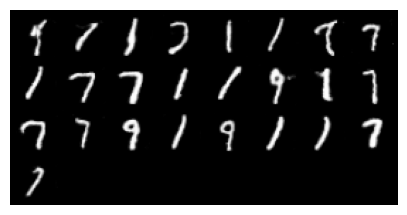

Epoch [41/50] | D Loss: 0.1313 | G Loss: 4.0919
Epoch [42/50] | D Loss: 0.2608 | G Loss: 2.0371
Epoch [43/50] | D Loss: 0.1302 | G Loss: 4.3498
Epoch [44/50] | D Loss: 0.4148 | G Loss: 3.6423
Epoch [45/50] | D Loss: 0.3272 | G Loss: 5.6624
Epoch [46/50] | D Loss: 0.1801 | G Loss: 4.1222
Epoch [47/50] | D Loss: 0.1702 | G Loss: 3.3759
Epoch [48/50] | D Loss: 0.2604 | G Loss: 4.5326
Epoch [49/50] | D Loss: 0.1654 | G Loss: 3.0628
Epoch [50/50] | D Loss: 0.1434 | G Loss: 4.8419


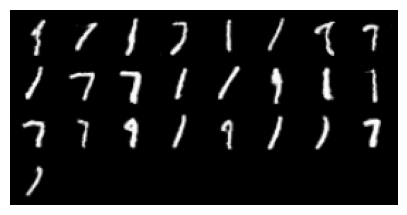

In [10]:
# Define necessary variables before training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100  # Size of the latent space

num_epochs = 50
fixed_noise = torch.randn(25, z_dim).to(device)  # For visualizing progress

for epoch in range(num_epochs):
    for imgs, _ in dataloader:
        imgs = imgs.to(device)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        real_loss = criterion(discriminator(imgs), real_labels)
        fake_imgs = generator(torch.randn(imgs.size(0), z_dim).to(device))  # Ensure z_dim is used correctly
        fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_loss = criterion(discriminator(fake_imgs), real_labels)
        fake_loss.backward()
        optimizer_G.step()

    # Print training progress
    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {fake_loss.item():.4f}")

    # Generate sample images every 10 epochs
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            sample_imgs = generator(fixed_noise).cpu()
        plt.figure(figsize=(5,5))
        plt.imshow(torchvision.utils.make_grid(sample_imgs, normalize=True).permute(1, 2, 0))
        plt.axis("off")
        plt.show()


In [11]:
print(len(dataloader))


938


In [ ]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class Generator(nn.Module):
    def __init__(self, z_dim, img_channels):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.img_channels = img_channels

        self.fc = nn.Linear(z_dim, 128)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise):
        quantum_input = noise[:, :n_qubits]
        quantum_output = torch.tensor([quantum_layer(q) for q in quantum_input]).to(noise.device)

        classical_input = noise[:, n_qubits:]
        merged_input = torch.cat((quantum_output, classical_input), dim=1)

        x = self.fc(merged_input).view(-1, 128, 1, 1)
        img = self.conv_layers(x)
        return img


In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 8 * 8, 1)  # 🔥 Adjusted based on actual output size
        self.sigmoid = nn.Sigmoid()

    def forward(self, img):
        x = self.conv_layers(img)
        x = self.flatten(x)
        x = self.fc(x)
        return self.sigmoid(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

z_dim = 100  # Latent space size
img_channels = 1  # MNIST has 1 channel (grayscale)

generator = Generator(z_dim, img_channels).to(device)
discriminator = Discriminator(img_channels).to(device)

criterion = nn.BCELoss()  # Binary Cross-Entropy loss for GAN
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
torch.save(generator.state_dict(), "quantum_gan_generator.pth")
print("Model saved!")


In [ ]:
generator.load_state_dict(torch.load("quantum_gan_generator.pth"))
generator.eval()

with torch.no_grad():
    noise = torch.randn(25, z_dim).to(device)
    generated_imgs = generator(noise).cpu()

plt.figure(figsize=(5, 5))
plt.imshow(torchvision.utils.make_grid(generated_imgs, normalize=True).permute(1, 2, 0))
plt.axis("off")
plt.show()
